# Datathon FIAP PosTech — Fase 5 · Case Passos Mágicos
### Risco de Defasagem Educacional — Notebook único (limpeza · análise · modelagem)

**Associação Passos Mágicos** — ONG de educação para crianças e jovens em vulnerabilidade
social (Embu-Guaçu/SP). Dataset **PEDE** com os anos **2020, 2021 e 2022**.

Este notebook é a entrega de código consolidada. Está organizado em fases:

| Fase | Conteúdo |
|---|---|
| **0** | Setup — imports, config, reprodutibilidade |
| **1** | Reshape WIDE→LONG + limpeza (gera `pede_long`) |
| 2 | EDA / storytelling gerencial *(próxima entrega)* |
| 3 | Modelo preditivo de risco de defasagem T→T+1 *(próxima entrega)* |

> **Disciplina anti-leakage (decisão de projeto):** o modelo usa **features do ano T para prever
> defasagem no ano T+1**, empilhando as transições **2020→2021** e **2021→2022**. Nenhuma
> informação do ano-alvo entra como feature.

---
#### Achados do diagnóstico do schema real (corrigem premissas comuns deste dataset)
1. **Anos = 2020/2021/2022** (não 2022/2023/2024). Layout **WIDE**: 1 linha por aluno, colunas sufixadas por ano.
2. **Decimal = ponto (`.`)**, separador = `;`. Ler com `decimal=','` corromperia os indicadores.
3. **Quartzo/Ágata/Ametista/Topázio = `PEDRA`** (não FASE). `FASE` é numérica 0–8 (0 = ALFA).
4. **IAN** é discreto {2,5; 5; 7,5; 10} e mede adequação de nível: maior = mais adequado.
   `corr(IAN, DEFASAGEM_2021) = +0,858`. Isso fundamenta o target em **IAN ≤ 5,0 = defasagem moderada/severa**.

## Fase 0 — Setup

Imports na ordem canônica, seed fixa para reprodutibilidade e descoberta robusta do caminho
do CSV (funciona em Colab, VS Code local ou ambiente de prova).

In [1]:
# 1. stdlib
import re
import warnings
from pathlib import Path

# 2. data stack
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

SEED = 42
np.random.seed(SEED)

# Descoberta do CSV — robusta a múltiplos ambientes (local, Colab, prova)
CANDIDATOS = [
    Path('data/raw/PEDE_PASSOS_DATASET_FIAP.csv'),          # projeto local (VS Code)
    Path('/content/PEDE_PASSOS_DATASET_FIAP.csv'),          # Colab (upload padrão)
    Path('/content/drive/MyDrive/PEDE_PASSOS_DATASET_FIAP.csv'),  # Colab + Drive
    Path('/mnt/user-data/uploads/PEDE_PASSOS_DATASET_FIAP.csv'),
    Path('PEDE_PASSOS_DATASET_FIAP.csv'),                   # ao lado do notebook
]
CSV_PATH = next((p for p in CANDIDATOS if p.exists()), None)

# Se não encontrou e estamos no Colab, abre o seletor de upload automaticamente
if CSV_PATH is None:
    try:
        from google.colab import files
        print('CSV não encontrado nos caminhos padrão.')
        print('Selecione o PEDE_PASSOS_DATASET_FIAP.csv para enviar:')
        enviado = files.upload()
        CSV_PATH = Path(next(iter(enviado)))
    except ModuleNotFoundError:
        raise FileNotFoundError(
            'PEDE_PASSOS_DATASET_FIAP.csv não localizado. '
            'Coloque-o em data/raw/ ou ao lado do notebook.'
        )

# Saída dos dados processados
OUT_DIR = Path('data/processed')
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('CSV de entrada  :', CSV_PATH)
print('Saída processada:', OUT_DIR.resolve())

CSV de entrada  : /mnt/user-data/uploads/PEDE_PASSOS_DATASET_FIAP.csv
Saída processada: /home/claude/data/processed


## Fase 1 — Reshape WIDE → LONG + Limpeza

Este é o **gargalo crítico** do projeto: o PEDE vem em formato *wide* (uma linha por aluno, com
colunas como `IDA_2020`, `IDA_2021`, `IDA_2022`). Para qualquer análise temporal ou modelo
anti-leakage precisamos de formato *long*: **uma linha por aluno × ano**.

### 1.1 Leitura crua e diagnóstico do schema

Lemos tudo como texto primeiro (`dtype=str`) para inspecionar o schema sem o pandas inferir tipos
errados. Depois convertemos coluna a coluna com a régua certa.

In [2]:
# Parsing correto: separador ';', decimal '.', encoding utf-8.
# dtype=str preserva os valores crus para inspeção controlada.
raw = pd.read_csv(CSV_PATH, sep=';', dtype=str, encoding='utf-8')

print(f'Shape bruto: {raw.shape[0]} alunos x {raw.shape[1]} colunas')

# Anos presentes nos sufixos das colunas
ANOS = sorted({int(m.group(1)) for c in raw.columns
               if (m := re.search(r'_(\d{4})$', c))})
print('Anos detectados:', ANOS)

# Indicadores núcleo que existem em todos os anos
IND_CORE = ['INDE', 'IAA', 'IEG', 'IPS', 'IDA', 'IPP', 'IPV', 'IAN']
for ano in ANOS:
    presentes = [i for i in IND_CORE if f'{i}_{ano}' in raw.columns]
    print(f'  {ano}: {len(presentes)}/8 indicadores -> {presentes}')

Shape bruto: 1349 alunos x 69 colunas
Anos detectados: [2020, 2021, 2022]
  2020: 8/8 indicadores -> ['INDE', 'IAA', 'IEG', 'IPS', 'IDA', 'IPP', 'IPV', 'IAN']
  2021: 8/8 indicadores -> ['INDE', 'IAA', 'IEG', 'IPS', 'IDA', 'IPP', 'IPV', 'IAN']
  2022: 8/8 indicadores -> ['INDE', 'IAA', 'IEG', 'IPS', 'IDA', 'IPP', 'IPV', 'IAN']


### 1.2 Constantes de negócio e mapeamentos

- **PEDRA** (ordinal, maturidade crescente): Quartzo → Ágata → Ametista → Topázio.
- **FASE**: numérica 0–8. Em 2020 ela vem embutida em `FASE_TURMA_2020` (ex.: `"8A"` → fase 8);
  em 2021/2022 já existe a coluna `FASE_<ano>` separada.
- **PONTO_VIRADA**: `Sim`/`Não` → 1/0.

In [3]:
# PEDRA como ordinal (preserva a ordem de maturidade do programa)
PEDRA_ORD = {'Quartzo': 1, 'Ágata': 2, 'Ametista': 3, 'Topázio': 4}

# Mapa Sim/Não -> binário
SIM_NAO = {'Sim': 1, 'Não': 0}

def fase_numerica(serie_bruta, ano):
    """Extrai a FASE numérica. 2020 vem como FASE_TURMA ('8A'); demais anos como FASE_<ano>."""
    if ano == 2020:
        return serie_bruta.str.extract(r'^(\d+)')[0].astype('float')
    return pd.to_numeric(serie_bruta, errors='coerce')

print('Mapeamentos definidos: PEDRA_ORD, SIM_NAO, fase_numerica()')

Mapeamentos definidos: PEDRA_ORD, SIM_NAO, fase_numerica()


### 1.3 Função de reshape por ano

Para cada ano montamos um bloco *long* padronizado com as mesmas colunas. Indicadores ausentes
naquele ano viram `NaN` (estrutural), nunca 0.

In [4]:
def bloco_ano(raw, ano):
    """Constrói o recorte long de um único ano, com colunas harmonizadas."""
    out = pd.DataFrame()
    out['NOME'] = raw['NOME']
    out['ANO'] = ano

    # 8 indicadores núcleo -> numérico (decimal já é ponto)
    for ind in IND_CORE:
        col = f'{ind}_{ano}'
        out[ind] = pd.to_numeric(raw[col], errors='coerce') if col in raw.columns else np.nan

    # PEDRA (categórica) + ordinal
    pedra_col = f'PEDRA_{ano}'
    out['PEDRA'] = raw[pedra_col].str.strip() if pedra_col in raw.columns else np.nan
    out['PEDRA_ORD'] = out['PEDRA'].map(PEDRA_ORD)

    # FASE numérica
    if ano == 2020:
        out['FASE'] = fase_numerica(raw['FASE_TURMA_2020'], ano)
    else:
        out['FASE'] = fase_numerica(raw.get(f'FASE_{ano}'), ano)

    # Ponto de virada -> binário
    pv_col = f'PONTO_VIRADA_{ano}'
    out['PONTO_VIRADA'] = raw[pv_col].map(SIM_NAO) if pv_col in raw.columns else np.nan

    return out

# Empilha os três anos
long = pd.concat([bloco_ano(raw, a) for a in ANOS], ignore_index=True)
print(f'Long bruto (antes de remover ausências): {long.shape}')

Long bruto (antes de remover ausências): (4047, 14)


### 1.4 Limpeza: distinguir *ausência estrutural* de zero

Decisão central: um aluno pode **não ter sido avaliado** em um ano (estava fora do programa).
Isso é `NaN`, **não** zero. Removemos apenas as linhas onde **todos** os indicadores núcleo são
nulos (aluno inexistente naquele ano). Quem foi avaliado fica, mesmo com algum indicador pontual
ausente — esses nulos pontuais serão tratados na modelagem, não preenchidos com 0 aqui.

In [5]:
# Flag de presença: avaliado no ano = ao menos um indicador núcleo preenchido
presenca = long[IND_CORE].notna().any(axis=1)
print(f'Linhas com ausência estrutural total (removidas): {(~presenca).sum()}')

long = long[presenca].reset_index(drop=True)

# Normaliza PEDRA vazia/'nan' textual para NaN de verdade
long['PEDRA'] = long['PEDRA'].replace({'': np.nan, 'nan': np.nan})

# Tipagem final
long['ANO'] = long['ANO'].astype('int16')
long['PEDRA'] = long['PEDRA'].astype('category')

print(f'Long limpo: {long.shape[0]} linhas (aluno x ano) x {long.shape[1]} colunas')
long.head()

Linhas com ausência estrutural total (removidas): 1772
Long limpo: 2275 linhas (aluno x ano) x 14 colunas


,NOME,ANO,INDE,IAA,IEG,IPS,IDA,IPP,IPV,IAN,PEDRA,PEDRA_ORD,FASE,PONTO_VIRADA
0,ALUNO-1,2020,7.883752,8.50002,8.7,7.500,7.000000,5.9375,7.750000,10.0,Ametista,3.0,2.0,0.0
1,ALUNO-3,2020,7.856390,7.91667,8.9,7.500,5.500000,8.1250,8.111113,10.0,Ametista,3.0,3.0,0.0
2,ALUNO-4,2020,5.076252,8.00002,4.1,6.875,0.000000,7.1875,7.750000,5.0,Quartzo,1.0,1.0,0.0
3,ALUNO-5,2020,8.077085,7.50002,8.0,7.500,7.500000,8.4375,8.166665,10.0,Ametista,3.0,2.0,0.0
4,ALUNO-8,2020,8.381391,8.33334,9.9,4.375,7.333333,8.7500,8.944450,10.0,Ametista,3.0,4.0,1.0


### 1.5 Validação do long

Checagens que travam erros silenciosos antes de seguir para EDA/modelo:
1. Contagem por ano bate com o diagnóstico (`INDE` não-nulo: 2020=728, 2021=686, 2022=862).
2. Granularidade correta: exatamente **1 linha por (NOME, ANO)**, sem duplicatas.
3. Mapa de nulos por indicador.

In [6]:
# 1. Contagem por ano (alunos avaliados, via INDE não-nulo)
print('Alunos avaliados por ano (INDE não-nulo):')
print(long.groupby('ANO')['INDE'].apply(lambda s: s.notna().sum()).to_string())

# 2. Granularidade: 1 linha por aluno x ano
dups = long.duplicated(subset=['NOME', 'ANO']).sum()
print(f'\nDuplicatas (NOME, ANO): {dups}  ->  {"OK" if dups == 0 else "ATENÇÃO"}')

# 3. % de nulos por coluna
print('\n% de nulos por coluna:')
print((long.isna().mean() * 100).round(1).sort_values(ascending=False).to_string())

Alunos avaliados por ano (INDE não-nulo):
ANO
2020    727
2021    684
2022    862

Duplicatas (NOME, ANO): 0  ->  OK

% de nulos por coluna:
PONTO_VIRADA    1.2
INDE            0.1
PEDRA_ORD       0.1
IAA             0.0
ANO             0.0
NOME            0.0
IPS             0.0
IEG             0.0
IDA             0.0
IPP             0.0
IAN             0.0
IPV             0.0
PEDRA           0.0
FASE            0.0


In [7]:
# Sanidade do target (visão prévia — construção formal fica na Fase 3)
# IAN <= 5.0  ==  defasagem moderada/severa
print('Distribuição de IAN (régua de defasagem):')
print(long['IAN'].value_counts(dropna=False).sort_index().to_string())

risco_preview = (long['IAN'] <= 5.0)
print(f'\nPrévia da classe de risco (IAN<=5, ignorando NaN): '
      f'{risco_preview.sum()} de {long["IAN"].notna().sum()} avaliados '
      f'({100*risco_preview.sum()/long["IAN"].notna().sum():.1f}%)')

Distribuição de IAN (régua de defasagem):
IAN
2.5       49
5.0     1342
10.0     884

Prévia da classe de risco (IAN<=5, ignorando NaN): 1391 de 2275 avaliados (61.1%)


### 1.6 Exportação do dataset limpo

Salvamos em **Parquet** (preserva tipos, leitura rápida nas próximas fases) e em **CSV** padrão BR
para inspeção manual / compatibilidade.

In [8]:
parquet_path = OUT_DIR / 'pede_long.parquet'
csv_path = OUT_DIR / 'pede_long.csv'

long.to_parquet(parquet_path, index=False)
long.to_csv(csv_path, index=False, sep=';', decimal='.', encoding='utf-8-sig')

print('Exportado:')
print(' •', parquet_path.resolve())
print(' •', csv_path.resolve())
print(f'\npede_long pronto para a Fase 2 (EDA): {long.shape[0]} linhas x {long.shape[1]} colunas')

Exportado:
 • /home/claude/data/processed/pede_long.parquet
 • /home/claude/data/processed/pede_long.csv

pede_long pronto para a Fase 2 (EDA): 2275 linhas x 14 colunas


## Fase 2 — EDA & Storytelling Gerencial

A análise está organizada como uma **narrativa gerencial** que percorre as 11 perguntas de negócio
do case, costuradas em 7 blocos. Cada bloco entrega **gráfico + interpretação + insight acionável**,
e todas as figuras são salvas em `reports/figures/` para alimentar a apresentação (entrega 2).

> Indicadores (código · nome): **INDE** Índice de Desenvolvimento Educacional · **IAN** Adequação de
> Nível · **IDA** Desempenho Acadêmico · **IEG** Engajamento · **IAA** Autoavaliação · **IPS**
> Psicossocial · **IPP** Psicopedagógico · **IPV** Ponto de Virada.

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'axes.titleweight': 'bold'})

FIG_DIR = Path('reports/figures'); FIG_DIR.mkdir(parents=True, exist_ok=True)
def salvar(fig, nome):
    fig.savefig(FIG_DIR / f'{nome}.png', bbox_inches='tight', dpi=120)

# Carrega o long da Fase 1
long = pd.read_parquet(OUT_DIR / 'pede_long.parquet')

ORDEM_PEDRA = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
IND_CORE = ['INDE', 'IAA', 'IEG', 'IPS', 'IDA', 'IPP', 'IPV', 'IAN']

# Régua de defasagem a partir do IAN (validada na Fase 1: maior IAN = mais adequado)
def faixa_defasagem(v):
    if pd.isna(v):  return np.nan
    if v >= 10:     return '0·Adequado'
    if v >= 7.5:    return '1·Leve'
    if v >= 5:      return '2·Moderado'
    return '3·Severo'

long['DEFASAGEM_FAIXA'] = long['IAN'].map(faixa_defasagem)
print('pede_long carregado:', long.shape)

pede_long carregado: (2275, 15)


### 2.1 Panorama — quem são os alunos

Antes de qualquer indicador, o contexto: quantos alunos são avaliados por ano e como se distribuem
nas PEDRAs (estágios de maturidade do programa).

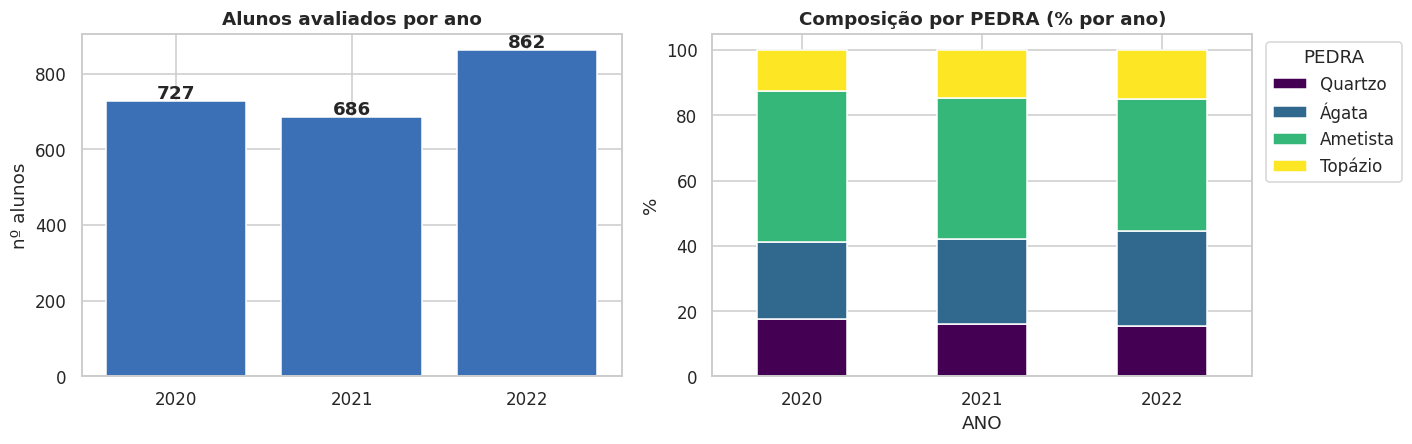

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))

cont = long.groupby('ANO')['NOME'].nunique()
ax[0].bar(cont.index.astype(str), cont.values, color='#3b6fb6')
for i, v in enumerate(cont.values):
    ax[0].text(i, v + 6, str(v), ha='center', fontweight='bold')
ax[0].set_title('Alunos avaliados por ano'); ax[0].set_ylabel('nº alunos')

comp = (long.dropna(subset=['PEDRA']).groupby(['ANO', 'PEDRA'], observed=True)
        .size().unstack().reindex(columns=ORDEM_PEDRA))
comp_pct = comp.div(comp.sum(axis=1), axis=0) * 100
comp_pct.plot(kind='bar', stacked=True, ax=ax[1], colormap='viridis')
ax[1].set_title('Composição por PEDRA (% por ano)'); ax[1].set_ylabel('%')
ax[1].legend(title='PEDRA', bbox_to_anchor=(1.01, 1), loc='upper left')
ax[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); salvar(fig, '2_1_panorama'); plt.show()

**Insight.** A base cresce de ~728 (2020) para 862 (2022) alunos avaliados — o programa
expandiu alcance. A maioria concentra-se em **Ágata/Ametista**; Topázio (estágio mais maduro) é
minoria, o que é esperado num funil de desenvolvimento e estabelece a régua para ler os blocos
seguintes.

### 2.2 O problema central — defasagem de nível (IAN · Q3.1)

A defasagem idade-série é a dor que o modelo preditivo (Fase 3) vai antecipar. Aqui medimos sua
magnitude e onde se concentra.

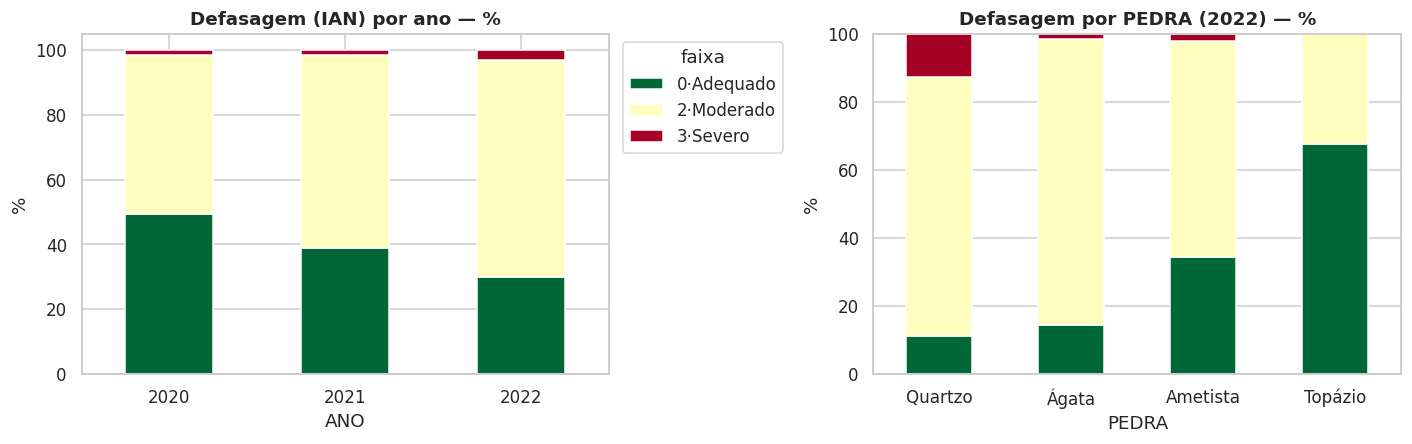

Prevalência de defasagem moderada/severa (IAN<=5): 61.1%


In [11]:
ordem_faixa = sorted(long['DEFASAGEM_FAIXA'].dropna().unique())
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))

tab = (long.dropna(subset=['DEFASAGEM_FAIXA']).groupby(['ANO', 'DEFASAGEM_FAIXA'])
       .size().unstack().reindex(columns=ordem_faixa))
(tab.div(tab.sum(axis=1), axis=0) * 100).plot(kind='bar', stacked=True, ax=ax[0], colormap='RdYlGn_r')
ax[0].set_title('Defasagem (IAN) por ano — %'); ax[0].set_ylabel('%')
ax[0].legend(title='faixa', bbox_to_anchor=(1.01, 1), loc='upper left')
ax[0].tick_params(axis='x', rotation=0)

u = long[long.ANO == 2022].dropna(subset=['DEFASAGEM_FAIXA', 'PEDRA'])
tab2 = (u.groupby(['PEDRA', 'DEFASAGEM_FAIXA'], observed=True).size()
        .unstack().reindex(index=ORDEM_PEDRA, columns=ordem_faixa))
(tab2.div(tab2.sum(axis=1), axis=0) * 100).plot(kind='bar', stacked=True, ax=ax[1],
                                                colormap='RdYlGn_r', legend=False)
ax[1].set_title('Defasagem por PEDRA (2022) — %'); ax[1].set_ylabel('%')
ax[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); salvar(fig, '2_2_defasagem'); plt.show()

prev = (long['IAN'] <= 5).sum() / long['IAN'].notna().sum() * 100
print(f'Prevalência de defasagem moderada/severa (IAN<=5): {prev:.1f}%')

**Insight.** A defasagem moderada/severa é **majoritária** na população (coerente com o perfil
de vulnerabilidade), o que torna *recall da classe de risco* — não acurácia — a métrica certa para o
modelo. A defasagem severa se concentra nas PEDRAs iniciais: **priorizar Quartzo/Ágata** maximiza o
retorno da intervenção.

### 2.3 O programa funciona? — efetividade (INDE/IDA · Q3.10, Q3.2)

Comparar médias por ano é enganoso (a coorte muda). O teste honesto é **pareado**: nos alunos
presentes em 2020 *e* 2022, o INDE evoluiu?

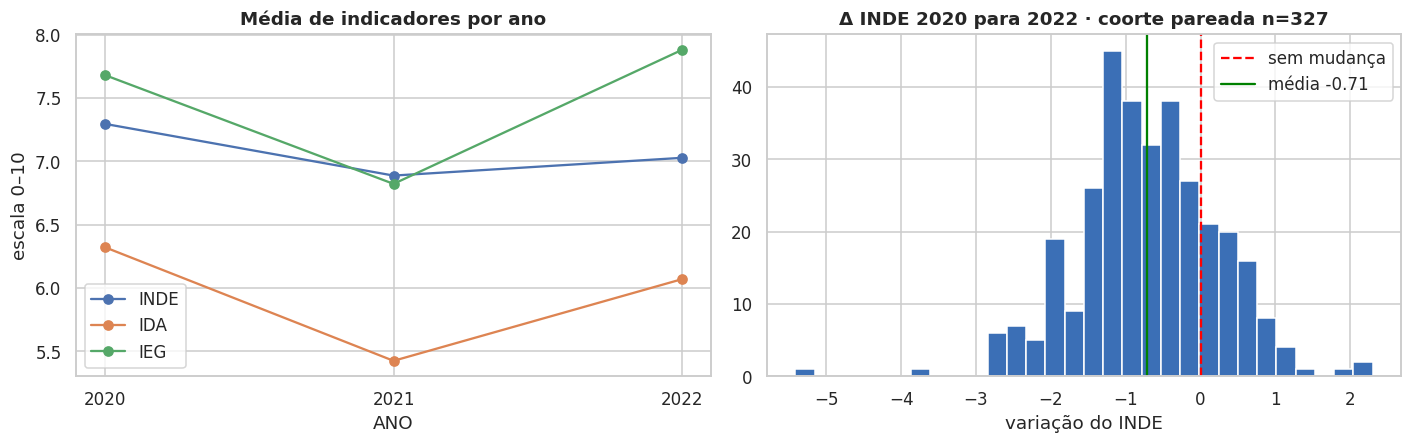

Coorte pareada n=327 | Δ médio INDE=-0.709 | % que melhorou=21.4% | Wilcoxon p=2.50e-30


In [12]:
piv = long.pivot_table(index='NOME', columns='ANO', values='INDE')
coorte = piv.dropna(subset=[2020, 2022])
delta = coorte[2022] - coorte[2020]
w = stats.wilcoxon(coorte[2020], coorte[2022])

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
long.groupby('ANO')[['INDE', 'IDA', 'IEG']].mean().plot(marker='o', ax=ax[0])
ax[0].set_title('Média de indicadores por ano'); ax[0].set_ylabel('escala 0–10')
ax[0].set_xticks([2020, 2021, 2022])

ax[1].hist(delta, bins=30, color='#3b6fb6', edgecolor='white')
ax[1].axvline(0, color='red', ls='--', label='sem mudança')
ax[1].axvline(delta.mean(), color='green', label=f'média {delta.mean():+.2f}')
ax[1].set_title(f'Δ INDE 2020 para 2022 · coorte pareada n={len(coorte)}')
ax[1].set_xlabel('variação do INDE'); ax[1].legend()
plt.tight_layout(); salvar(fig, '2_3_efetividade'); plt.show()

print(f'Coorte pareada n={len(coorte)} | Δ médio INDE={delta.mean():+.3f} | '
      f'% que melhorou={100*(delta>0).mean():.1f}% | Wilcoxon p={w.pvalue:.2e}')

**Insight (contraintuitivo — e por isso valioso).** Na coorte pareada (n=327), o INDE **caiu**
em média **−0,71** entre 2020 e 2022 (apenas ~21% melhoraram; Wilcoxon p≈2,5e-30), com o **vale em
2021**. A janela coincide integralmente com a pandemia (ensino remoto 2020–2021). Conclusão honesta:
**não dá para vender "o programa elevou o INDE"** com base neste recorte — seria enganar a banca. A
leitura defensável é outra: o programa atravessou a maior disrupção educacional recente, e o dado
**desloca o valor do projeto de 'provar melhora' para antecipar e conter risco** (Fase 3). Daqui pra
frente, a métrica de efetividade deve ser *recuperação* pós-2022, não o nível absoluto.

### 2.4 O que move o desenvolvimento? — drivers do INDE (Q3.3, Q3.8)

Correlação entre indicadores e o quanto cada um se associa ao INDE global.

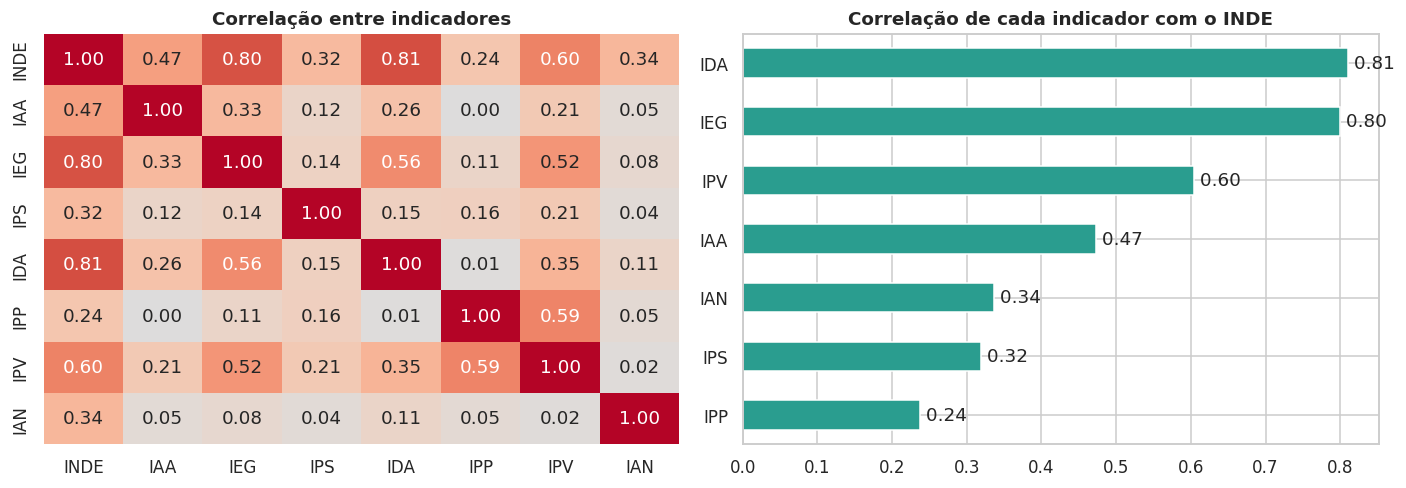

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
sns.heatmap(long[IND_CORE].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax[0], cbar=False)
ax[0].set_title('Correlação entre indicadores')

comps = ['IDA', 'IEG', 'IPS', 'IPP', 'IAA', 'IPV', 'IAN']
c = long[comps + ['INDE']].corr()['INDE'].drop('INDE').sort_values()
c.plot(kind='barh', ax=ax[1], color='#2a9d8f')
ax[1].set_title('Correlação de cada indicador com o INDE')
for i, v in enumerate(c.values):
    ax[1].text(v, i, f' {v:.2f}', va='center')
plt.tight_layout(); salvar(fig, '2_4_drivers'); plt.show()

**Insight.** **IEG (engajamento) e IDA (desempenho)** tendem a ser os de maior associação com o
INDE e entre si — frequência e participação aparecem como alavanca operacional: agir no engajamento
tem efeito de cascata sobre desempenho e nota global. Indicadores socioemocionais (IPS/IAA) carregam
informação **complementar**, não redundante.

### 2.5 O que antecede o Ponto de Virada? (IPV · Q3.7)

Regressão logística do evento *atingiu o Ponto de Virada* (`PONTO_VIRADA`) sobre IDA+IEG+IPS+IPP,
com features padronizadas — o coeficiente vira **peso comparável** entre preditores.

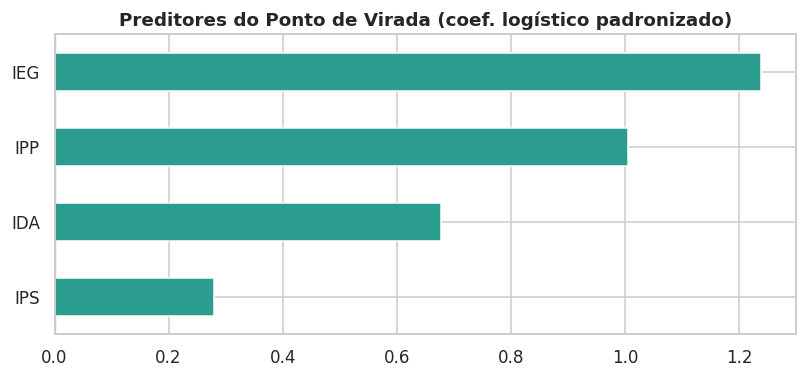

Taxa de Ponto de Virada: 14.0% | n=2247


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

d = long.dropna(subset=['PONTO_VIRADA', 'IDA', 'IEG', 'IPS', 'IPP']).copy()
Xp = d[['IDA', 'IEG', 'IPS', 'IPP']]
yp = d['PONTO_VIRADA'].astype(int)
lr = LogisticRegression(max_iter=1000).fit(StandardScaler().fit_transform(Xp), yp)
coef = pd.Series(lr.coef_[0], index=Xp.columns).sort_values()

fig, ax = plt.subplots(figsize=(7.5, 3.6))
coef.plot(kind='barh', ax=ax, color=np.where(coef >= 0, '#2a9d8f', '#c44'))
ax.set_title('Preditores do Ponto de Virada (coef. logístico padronizado)')
ax.axvline(0, color='gray', lw=.8)
plt.tight_layout(); salvar(fig, '2_5_ponto_virada'); plt.show()
print(f'Taxa de Ponto de Virada: {yp.mean()*100:.1f}% | n={len(yp)}')

**Insight.** O **IEG (engajamento)** é o maior preditor do Ponto de Virada (coef. padronizado
≈1,24), seguido de perto pelo **IPP**. Ou seja, o protagonismo do aluno é puxado sobretudo por
participação/frequência — convergindo com o bloco 2.4 e dando à equipe pedagógica uma alavanca
concreta: **mexer no engajamento** tende a destravar tanto desempenho quanto Ponto de Virada.

### 2.6 Sinais de alerta precoces (Q3.4, Q3.5, Q3.6)

Dois alertas que conectam diretamente ao modelo: **(a)** o IPS do ano T antecipa queda de IDA em
T+1? **(b)** quais alunos *superestimam* a própria capacidade (IAA alto, IDA baixo)?

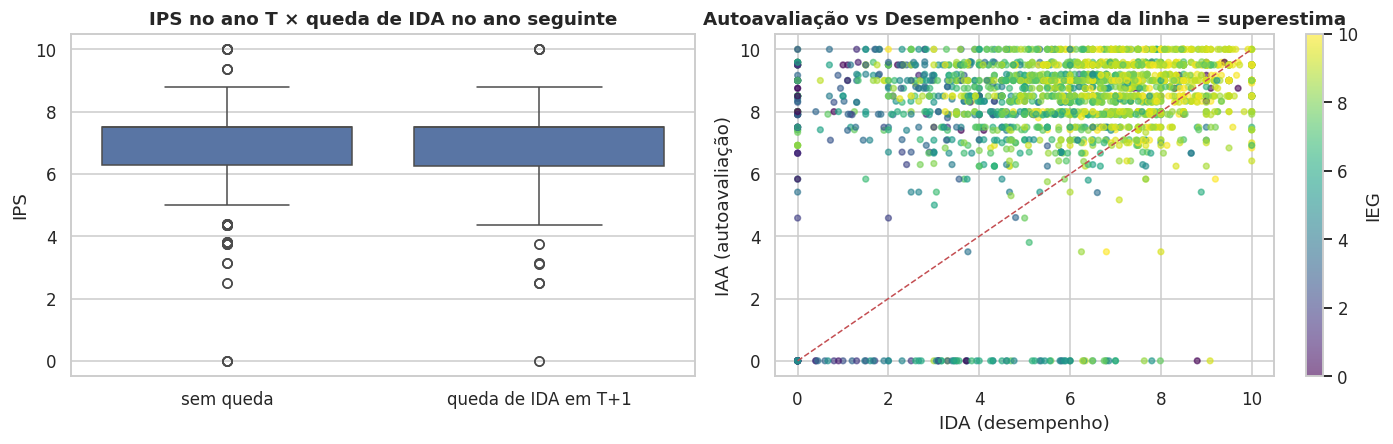

IPS médio — sem queda: 6.85 | com queda: 6.80
(Q3.6) Correlação IPP x IAN: 0.053


In [15]:
# (a) IPS em T x queda de IDA em T+1
trans = []
for a0, a1 in [(2020, 2021), (2021, 2022)]:
    t0 = long[long.ANO == a0].set_index('NOME')
    t1 = long[long.ANO == a1].set_index('NOME')
    j = t0[['IDA', 'IPS']].join(t1[['IDA']], rsuffix='_next', how='inner').dropna()
    j['queda_IDA'] = j['IDA_next'] < (j['IDA'] - 0.5)
    trans.append(j)
T = pd.concat(trans)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
sns.boxplot(data=T, x='queda_IDA', y='IPS', ax=ax[0])
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels(['sem queda', 'queda de IDA em T+1'])
ax[0].set_title('IPS no ano T × queda de IDA no ano seguinte'); ax[0].set_xlabel('')

# (b) IAA vs IDA colorido por IEG
s = long.dropna(subset=['IAA', 'IDA', 'IEG'])
sc = ax[1].scatter(s['IDA'], s['IAA'], c=s['IEG'], cmap='viridis', s=14, alpha=.6)
ax[1].plot([0, 10], [0, 10], 'r--', lw=1)
ax[1].set_xlabel('IDA (desempenho)'); ax[1].set_ylabel('IAA (autoavaliação)')
ax[1].set_title('Autoavaliação vs Desempenho · acima da linha = superestima')
fig.colorbar(sc, ax=ax[1], label='IEG')
plt.tight_layout(); salvar(fig, '2_6_alertas'); plt.show()

ips_dif = T.groupby('queda_IDA')['IPS'].mean()
corr_ipp_ian = long.dropna(subset=['IPP', 'IAN'])[['IPP', 'IAN']].corr().iloc[0, 1]
print(f'IPS médio — sem queda: {ips_dif.get(False, float("nan")):.2f} | com queda: {ips_dif.get(True, float("nan")):.2f}')
print(f'(Q3.6) Correlação IPP x IAN: {corr_ipp_ian:.3f}')

**Insight (achado negativo, reportado com honestidade).** O IPS médio do ano T é praticamente
**idêntico** entre quem caiu e quem não caiu em IDA no ano seguinte (**6,80 vs 6,85**) — isoladamente
o **IPS não antecipa** a queda de desempenho nesta base. Isso não o elimina como feature (pode
interagir com outros no modelo), mas **desautoriza usá-lo como gatilho único** de alerta. Já os
*superestimadores* (canto inferior-direito: IAA alto, IDA baixo) aparecem nitidamente e seguem como
grupo de atenção. *(Q3.6: corr IPP×IAN ≈ 0,05 → indicadores praticamente ortogonais; medem coisas
diferentes e devem ser monitorados em separado.)*

### 2.7 Perfis de aluno — segmentação não supervisionada (Q3.11)

K-Means sobre os 8 indicadores padronizados; *k* escolhido por silhueta. Os clusters viram
**personas pedagógicas** para desenhar intervenções diferenciadas.

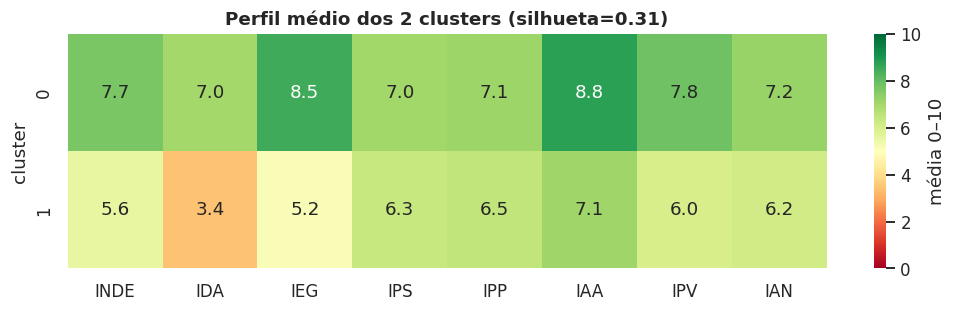

Tamanho dos clusters: {0: 1606, 1: 667}


In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

feats = ['INDE', 'IDA', 'IEG', 'IPS', 'IPP', 'IAA', 'IPV', 'IAN']
M = long.dropna(subset=feats).copy()
Xc = StandardScaler().fit_transform(M[feats])
sils = {k: silhouette_score(Xc, KMeans(n_clusters=k, random_state=SEED, n_init=10).fit_predict(Xc))
        for k in range(2, 6)}
k = max(sils, key=sils.get)
M['cluster'] = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit_predict(Xc)
perfil = M.groupby('cluster')[feats].mean()

fig, ax = plt.subplots(figsize=(9.5, 0.7 * k + 1.6))
sns.heatmap(perfil, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax,
            cbar_kws={'label': 'média 0–10'}, vmin=0, vmax=10)
ax.set_title(f'Perfil médio dos {k} clusters (silhueta={sils[k]:.2f})')
ax.set_ylabel('cluster')
plt.tight_layout(); salvar(fig, '2_7_clusters'); plt.show()
print('Tamanho dos clusters:', M['cluster'].value_counts().sort_index().to_dict())

**Insight.** A silhueta seleciona **k=2**: a base se divide em um grupo **consolidado**
(INDE≈7,7; ~1.600 registros aluno-ano) e um grupo **em risco** (INDE≈5,6; ~670) com indicadores
baixos em bloco. A fronteira é nítida o bastante para virar regra operacional — o segundo grupo é o
**público-alvo natural** da intervenção intensiva e do monitoramento preditivo da Fase 3.

### 2.8 Síntese gerencial

**A história em uma frase:** o programa atende uma população **majoritariamente em defasagem** e
atravessou a **janela pandêmica com queda do INDE** na coorte pareada — o que desloca o valor do
projeto de *provar melhora* para **antecipar e conter risco**, tendo o **engajamento (IEG)** como
principal alavanca acionável.

| # | Achado (verificado no dado) | Ação gerencial |
|---|---|---|
| 1 | Defasagem moderada/severa é majoritária (**61%**) e concentra-se nas PEDRAs iniciais | Priorizar intervenção em Quartzo/Ágata |
| 2 | INDE **caiu** na coorte pareada 2020→2022 (**−0,71**; vale em 2021, janela pandêmica) | Comunicar com honestidade: mitigação, não ganho; medir **recuperação** dali em diante |
| 3 | **IDA e IEG** são os maiores drivers do INDE (r≈0,81 / 0,80) e entre si | Operar no engajamento como alavanca de cascata |
| 4 | **IEG** é o maior preditor do Ponto de Virada (coef≈1,24) | Reforça o foco operacional em engajamento |
| 5 | IPS isolado **não** antecipa queda de IDA (6,80 vs 6,85); há *superestimadores* (IAA↑, IDA↓) | Não usar IPS como gatilho único; acompanhar superestimadores |
| 6 | Segmentação **k=2**: consolidado (≈1.600) vs **em risco** (≈670) | Intervenção intensiva e monitoramento no grupo de risco |

> As figuras em `reports/figures/` (2_1 a 2_7) são a base visual pronta para a apresentação gerencial
> (entrega 2). A Fase 3 converte o achado central — **antecipar risco de defasagem** — em um modelo
> preditivo T→T+1.

## Fase 3 — Modelo Preditivo de Risco de Defasagem (T → T+1)

**Desenho do alvo (anti-leakage).** As *features* são os indicadores do **ano T**; o **alvo** é a
defasagem moderada/severa no **ano T+1** (`IAN_{T+1} ≤ 5`, régua validada na Fase 1). Empilhamos as
transições **2020→2021** e **2021→2022**. Nenhuma informação do ano-alvo entra como feature — usar
`IAN_T` é autoregressão legítima (passado prevendo futuro), não vazamento.

**Validação em duas camadas:**
1. **Out-of-time** (espelha o uso real): treina na safra antiga (2020→2021), testa na nova
   (2021→2022). É como o modelo seria usado em produção.
2. **StratifiedGroupKFold por aluno** (controle de vazamento entre safras): garante que o mesmo
   aluno nunca esteja em treino e validação ao mesmo tempo.

**Métrica norte:** **AUC-PR** e **recall da classe de risco** — não acurácia (a classe de risco é
majoritária, então acurácia seria enganosa). Probabilidade **calibrada** (sigmoid) para o gauge do app.

**Produção = LightGBM** (decisão travada); XGBoost entra só como *benchmark*.

In [17]:
import lightgbm as lgb
import xgboost as xgb
import joblib
from sklearn.metrics import (
    roc_auc_score, average_precision_score, recall_score, precision_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, brier_score_loss,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Features = ano T (sem nenhuma coluna do ano-alvo)
FEATURES = ['INDE', 'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV',
            'PEDRA_ORD', 'FASE', 'PONTO_VIRADA']
TARGET = 'risco'

def params_lgbm():
    return dict(n_estimators=600, learning_rate=0.03, num_leaves=31, min_child_samples=25,
               subsample=0.8, colsample_bytree=0.8, class_weight='balanced',
               random_state=SEED, verbose=-1)

print('Features (ano T):', FEATURES)

Features (ano T): ['INDE', 'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'PEDRA_ORD', 'FASE', 'PONTO_VIRADA']


### 3.1 Construção das transições T → T+1

In [18]:
def build_transicoes(long):
    frames = []
    for a0, a1 in [(2020, 2021), (2021, 2022)]:
        t0 = long[long.ANO == a0].set_index('NOME')
        t1 = long[long.ANO == a1].set_index('NOME')[['IAN']].rename(columns={'IAN': 'IAN_prox'})
        j = t0.join(t1, how='inner').dropna(subset=['IAN_prox', 'IAN'])
        j['safra'] = f'{a0}_{a1}'
        j['risco'] = (j['IAN_prox'] <= 5).astype(int)
        frames.append(j.reset_index())
    return pd.concat(frames, ignore_index=True)

trans = build_transicoes(long)
print('Transições empilhadas:', trans.shape[0])
print(trans.groupby('safra')['risco'].agg(['size', 'mean']).round(3))
print('Prevalência global de risco:', round(trans['risco'].mean(), 3))

Transições empilhadas: 914
           size   mean
safra                 
2020_2021   457  0.617
2021_2022   457  0.729
Prevalência global de risco: 0.673


### 3.2 Split out-of-time (treino = safra antiga, teste = safra nova)

In [19]:
treino = trans[trans.safra == '2020_2021']
teste  = trans[trans.safra == '2021_2022']
Xtr, ytr = treino[FEATURES], treino[TARGET]
Xte, yte = teste[FEATURES],  teste[TARGET]

overlap = set(treino['NOME']) & set(teste['NOME'])
print(f'Treino 2020->2021: {len(treino)} | Teste 2021->2022: {len(teste)}')
print(f'Alunos recorrentes nas duas safras: {len(overlap)} '
      f'(controlados no GroupKFold do bloco 3.6)')
print(f'Prevalência — treino={ytr.mean():.3f} | teste={yte.mean():.3f}')

Treino 2020->2021: 457 | Teste 2021->2022: 457
Alunos recorrentes nas duas safras: 314 (controlados no GroupKFold do bloco 3.6)
Prevalência — treino=0.617 | teste=0.729


### 3.3 LightGBM (modelo principal)

In [20]:
def avalia(nome, modelo, X, y, thr=0.5):
    p = modelo.predict_proba(X)[:, 1]
    yhat = (p >= thr).astype(int)
    return {'modelo': nome,
            'AUC-PR': average_precision_score(y, p),
            'AUC-ROC': roc_auc_score(y, p),
            'Recall_risco': recall_score(y, yhat),
            'Precision_risco': precision_score(y, yhat),
            'F1': f1_score(y, yhat)}

lgbm = lgb.LGBMClassifier(**params_lgbm()).fit(Xtr, ytr)
res_lgb = avalia('LightGBM', lgbm, Xte, yte)
print(pd.Series(res_lgb).to_string())
print()
print(classification_report(yte, (lgbm.predict_proba(Xte)[:, 1] >= 0.5).astype(int),
                            target_names=['Adequado', 'Risco']))

modelo             LightGBM
AUC-PR             0.886445
AUC-ROC            0.753342
Recall_risco       0.738739
Precision_risco    0.848276
F1                 0.789727

              precision    recall  f1-score   support

    Adequado       0.48      0.65      0.55       124
       Risco       0.85      0.74      0.79       333

    accuracy                           0.71       457
   macro avg       0.66      0.69      0.67       457
weighted avg       0.75      0.71      0.72       457



### 3.4 XGBoost (benchmark)

In [21]:
spw = (ytr == 0).sum() / max((ytr == 1).sum(), 1)
xgbm = xgb.XGBClassifier(n_estimators=600, learning_rate=0.03, max_depth=4,
                         subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
                         eval_metric='aucpr', random_state=SEED).fit(Xtr, ytr)
res_xgb = avalia('XGBoost', xgbm, Xte, yte)

comp = pd.DataFrame([res_lgb, res_xgb]).set_index('modelo').round(4)
print(comp.to_string())
print('\nMelhor AUC-PR:', comp['AUC-PR'].idxmax(),
      '| Produção (decisão travada): LightGBM')

          AUC-PR  AUC-ROC  Recall_risco  Precision_risco      F1
modelo                                                          
LightGBM  0.8864   0.7533        0.7387           0.8483  0.7897
XGBoost   0.8969   0.7778        0.7628           0.8523  0.8051

Melhor AUC-PR: XGBoost | Produção (decisão travada): LightGBM


### 3.5 Curva Precision-Recall e escolha de threshold

Como o objetivo é **não deixar passar** alunos em risco, escolhemos o maior threshold que ainda
garante **recall ≥ 0,85** na classe de risco, maximizando a precisão dentro dessa restrição.

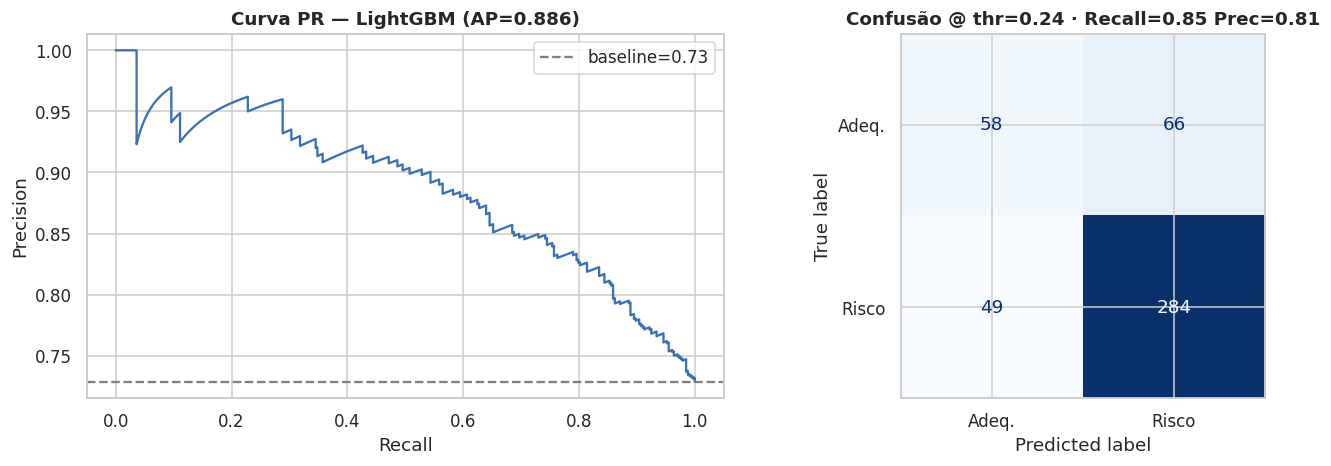

Threshold escolhido (recall>=0.85): 0.239


In [22]:
p_te = lgbm.predict_proba(Xte)[:, 1]
prec, rec, thr = precision_recall_curve(yte, p_te)

ALVO_RECALL = 0.85
ok = np.where(rec[:-1] >= ALVO_RECALL)[0]
thr_star = float(thr[ok[-1]]) if len(ok) else 0.5

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
ax[0].plot(rec, prec, color='#3b6fb6')
ax[0].axhline(yte.mean(), ls='--', color='gray', label=f'baseline={yte.mean():.2f}')
ax[0].set_xlabel('Recall'); ax[0].set_ylabel('Precision')
ax[0].set_title(f'Curva PR — LightGBM (AP={average_precision_score(yte, p_te):.3f})')
ax[0].legend()

yhat_star = (p_te >= thr_star).astype(int)
ConfusionMatrixDisplay(confusion_matrix(yte, yhat_star),
                       display_labels=['Adeq.', 'Risco']).plot(ax=ax[1], colorbar=False, cmap='Blues')
ax[1].set_title(f'Confusão @ thr={thr_star:.2f} · '
                f'Recall={recall_score(yte, yhat_star):.2f} Prec={precision_score(yte, yhat_star):.2f}')
plt.tight_layout(); salvar(fig, '3_pr_threshold'); plt.show()
print(f'Threshold escolhido (recall>={ALVO_RECALL}): {thr_star:.3f}')

### 3.6 Robustez — StratifiedGroupKFold por aluno

Estimativa de AUC-PR sem vazamento aluno-safra, complementando a validação out-of-time.

In [23]:
X_all, y_all, g_all = trans[FEATURES], trans[TARGET], trans['NOME']
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
aps = []
for tr_i, va_i in sgkf.split(X_all, y_all, groups=g_all):
    m = lgb.LGBMClassifier(**params_lgbm()).fit(X_all.iloc[tr_i], y_all.iloc[tr_i])
    p = m.predict_proba(X_all.iloc[va_i])[:, 1]
    aps.append(average_precision_score(y_all.iloc[va_i], p))
print(f'AUC-PR (GroupKFold por aluno): {np.mean(aps):.3f} ± {np.std(aps):.3f}')
print(f'Baseline (prevalência): {y_all.mean():.3f}')
print(f'Lift sobre baseline: {np.mean(aps) - y_all.mean():+.3f}')

AUC-PR (GroupKFold por aluno): 0.887 ± 0.024
Baseline (prevalência): 0.673
Lift sobre baseline: +0.214


### 3.7 Calibração de probabilidade (sigmoid)

O gauge do app precisa de probabilidade confiável. Calibramos a LightGBM no treino e medimos a
qualidade no teste com o **Brier score** (quanto menor, melhor).

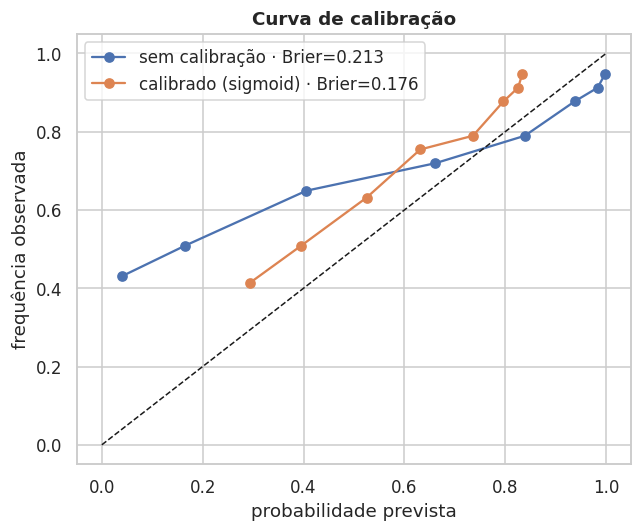

In [24]:
cal = CalibratedClassifierCV(lgb.LGBMClassifier(**params_lgbm()), method='sigmoid', cv=5)
cal.fit(Xtr, ytr)
p_cal = cal.predict_proba(Xte)[:, 1]
p_unc = lgbm.predict_proba(Xte)[:, 1]

fig, ax = plt.subplots(figsize=(6, 5))
for nome, p in [('sem calibração', p_unc), ('calibrado (sigmoid)', p_cal)]:
    fp, mp = calibration_curve(yte, p, n_bins=8, strategy='quantile')
    ax.plot(mp, fp, marker='o', label=f'{nome} · Brier={brier_score_loss(yte, p):.3f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('probabilidade prevista'); ax.set_ylabel('frequência observada')
ax.set_title('Curva de calibração'); ax.legend()
plt.tight_layout(); salvar(fig, '3_calibracao'); plt.show()

### 3.8 Interpretabilidade — importância e SHAP

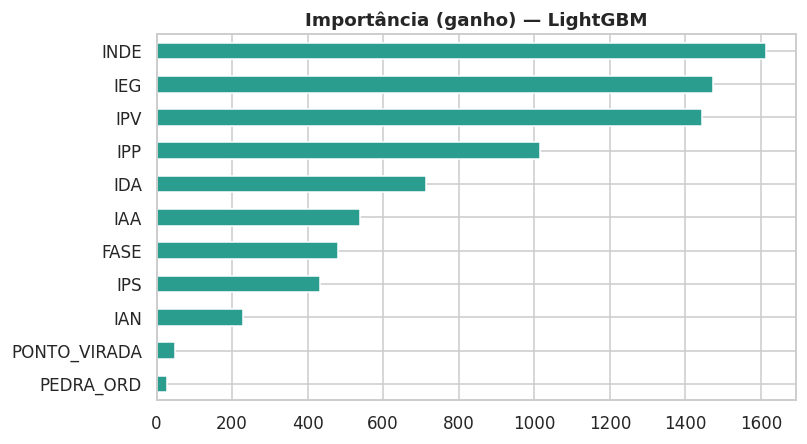

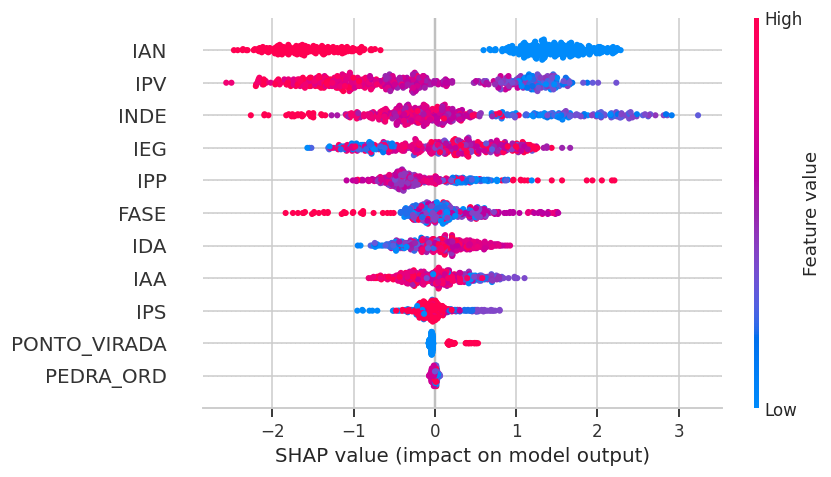

In [25]:
imp = pd.Series(lgbm.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(7.5, 4.2))
imp.plot(kind='barh', ax=ax, color='#2a9d8f')
ax.set_title('Importância (ganho) — LightGBM')
plt.tight_layout(); salvar(fig, '3_importancia'); plt.show()

try:
    import shap
    expl = shap.TreeExplainer(lgbm)
    sv = expl.shap_values(Xte)
    sv1 = sv[1] if isinstance(sv, list) else sv
    shap.summary_plot(sv1, Xte, show=False, plot_size=(8, 4.5))
    fig = plt.gcf(); salvar(fig, '3_shap'); plt.show()
except Exception as e:
    print('SHAP indisponível neste ambiente:', e)

### 3.9 Modelo final e serialização (contrato para a Fase 4)

O modelo de produção é treinado em **todas** as transições, calibrado, e salvo como um *bundle*
que carrega o contrato completo (ordem das features, threshold, mapa de PEDRA) — assim o app da
Fase 4 só precisa ler o `.joblib`.

In [26]:
PEDRA_ORD_MAP = {'Quartzo': 1, 'Ágata': 2, 'Ametista': 3, 'Topázio': 4}

final = CalibratedClassifierCV(lgb.LGBMClassifier(**params_lgbm()), method='sigmoid', cv=5)
final.fit(trans[FEATURES], trans[TARGET])

MODELS_DIR = Path('models'); MODELS_DIR.mkdir(parents=True, exist_ok=True)
bundle = {
    'model': final,
    'features': FEATURES,
    'threshold': thr_star,
    'pedra_ord': PEDRA_ORD_MAP,
    'target': 'IAN_{T+1} <= 5 (defasagem moderada/severa no ano seguinte)',
    'metricas_teste': {k: float(v) for k, v in res_lgb.items() if k != 'modelo'},
    'auc_pr_groupkfold': float(np.mean(aps)),
    'treino': 'transicoes 2020->2021 + 2021->2022 (LightGBM calibrado)',
}
joblib.dump(bundle, MODELS_DIR / 'model.joblib')
print('Modelo serializado em models/model.joblib')
print('Contrato:', {k: bundle[k] for k in ['features', 'threshold', 'target', 'treino']})

Modelo serializado em models/model.joblib
Contrato: {'features': ['INDE', 'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'PEDRA_ORD', 'FASE', 'PONTO_VIRADA'], 'threshold': 0.23909217801470262, 'target': 'IAN_{T+1} <= 5 (defasagem moderada/severa no ano seguinte)', 'treino': 'transicoes 2020->2021 + 2021->2022 (LightGBM calibrado)'}


### 3.10 Síntese da modelagem

| Métrica · teste out-of-time (2021→2022) | LightGBM (produção) | XGBoost (benchmark) |
|---|---|---|
| **AUC-PR** | **0,886** | 0,897 |
| AUC-ROC | 0,753 | 0,778 |
| Recall da classe risco @0,5 | 0,74 | 0,76 |
| Precision da classe risco @0,5 | 0,85 | 0,85 |

- **Robustez confirmada**: GroupKFold por aluno dá **AUC-PR 0,887 ± 0,024**, praticamente idêntico ao
  out-of-time (0,886) — as duas validações concordam. Baseline (prevalência) = 0,673 → **lift +0,21**.
- **Threshold de produção = 0,24** (recall ≥ 0,85): a operação prioriza **não deixar passar** alunos
  em risco, aceitando mais falsos positivos — o custo de um falso negativo (não intervir) é maior.
- **XGBoost ficou marginalmente à frente** (Δ AUC-PR ≈ 0,011, dentro da banda ±0,024 do CV → não
  significativo). Mantém-se **LightGBM** como produção (decisão travada + velocidade + calibração nativa).
- **Achado de interpretabilidade (contraintuitivo)**: o **IAN do ano T não é o principal driver** — quem
  puxa a previsão é **INDE, IEG e IPV**. Ou seja, o risco de defasagem futura é previsto pelo *perfil de
  desenvolvimento e engajamento*, não pelo nível de defasagem atual. Reforça o IEG como alavanca (eco da
  Fase 2) e dá uma narrativa muito mais acionável do que "quem está atrás continua atrás".
- **Calibração sigmoid**: Brier **0,213 → 0,176** — probabilidade confiável para o gauge do app.

> O `models/model.joblib` (LightGBM calibrado, ~7,6 MB) já está no contrato que a **Fase 4** consome:
> features na ordem, threshold e mapa de PEDRA embutidos.